# **Máquinas de Boltzmann Profundas y PyramidNet**

---

> *Modelos generativos profundos y redes residuales piramidales: fundamentos, matemáticas e implementación interactiva.*

**Grupo 9 — Redes Neuronales**

| Integrante | Correo |
|---|---|
| Juan Andrés Vallejo Rozo | juvallejor@unal.edu.co |
| Andrés Felipe Rojas Aguilar | arojasag@unal.edu.co |
| Brayan Camilo Rodríguez Díaz | brrodriguezd@unal.edu.co |
| Carlos David Ramírez Muñoz | cramirezmun@unal.edu.co |


---
# PARTE I — Máquinas de Boltzmann Profundas

## Introducción

### Modelos basados en energía

Los **modelos basados en energía** (*energy-based models*, EBM) son una familia de modelos probabilísticos que asignan un escalar (energía) a cada configuración posible de variables. La distribución de probabilidad se define como:

$$
p(x) = \frac{\exp(-E(x))}{Z}
$$

donde $Z = \sum_x \exp(-E(x))$ es la **función de partición** (constante normalizadora). Las configuraciones de baja energía son altamente probables; las de alta energía son improbables.

### Evolución histórica

```
1983 — Máquina de Boltzmann (BM)  →  Hinton & Sejnowski
       Aprendizaje intractable (cadenas de Markov lentas)
         ↓
1986 — RBM (Smolensky)  →  Sin conexiones intra-capa
       Inferencia exacta, aprendizaje eficiente con CD
         ↓
2006 — Deep Belief Network (DBN)  →  Hinton et al.
       Pre-entrenamiento capa por capa, pero modelo híbrido
         ↓
2009 — Deep Boltzmann Machine (DBM)  →  Salakhutdinov & Hinton
       Múltiples capas ocultas, completamente no-dirigido
       Inferencia top-down + bottom-up
```

### ¿Por qué DBM y no solo RBM?

* Las RBMs solo tienen **una capa oculta** → representaciones limitadas.
* Las DBMs construyen **jerarquías de características** (bordes → partes → objetos).
* A diferencia de las DBN, las DBMs son **completamente no-dirigidas**: la inferencia puede incorporar retroalimentación *top-down*, manejando mejor entradas ambiguas.
* Son modelos **generativos**: pueden muestrear datos nuevos y plausibles.


---
## Conceptos Clave — Máquinas de Boltzmann

### 2.1 Máquina de Boltzmann General (BM)

Una BM es una red de unidades binarias estocásticas simétricamente acopladas.

* **Unidades visibles** $v \in \{0,1\}^D$: representan los datos observables.
* **Unidades ocultas** $h \in \{0,1\}^P$: representan características latentes.

**Función de energía:**

$$
E(v, h;\, \theta) = -\frac{1}{2}\, v^\top L\, v \;-\; \frac{1}{2}\, h^\top J\, h \;-\; v^\top W\, h
$$

donde $\theta = \{W, L, J\}$:

| Matriz | Conexiones |
|---|---|
| $W$ | visible–oculto |
| $L$ | visible–visible |
| $J$ | oculto–oculto |

**Distribución de probabilidad:**

$$
p(v;\, \theta) = \frac{1}{Z(\theta)} \sum_h \exp(-E(v, h;\, \theta))
\qquad
Z(\theta) = \sum_v \sum_h \exp(-E(v, h;\, \theta))
$$

**Distribuciones condicionales** (logísticas):

$$
p(h_j = 1 \mid v, h_{-j}) = \sigma\!\left(\sum_i W_{ij}\, v_i + \sum_{m \neq j} J_{jm}\, h_m\right)
$$

$$
p(v_i = 1 \mid h, v_{-i}) = \sigma\!\left(\sum_j W_{ij}\, h_j + \sum_{k \neq i} L_{ik}\, v_k\right)
$$

donde $\sigma(x) = 1/(1 + e^{-x})$ es la función sigmoide.

---

### 2.2 Máquina de Boltzmann Restringida (RBM)

Al fijar $L = 0$ y $J = 0$, se obtiene la **RBM**: sin conexiones dentro de capas.

```
   h₁  h₂  h₃  h₄       ← capa oculta (no conectada entre sí)
    ╲╱╲╱╲╱╲╱
   v₁  v₂  v₃  v₄       ← capa visible (no conectada entre sí)
```

**Ventaja clave**: las unidades de cada capa son **condicionalmente independientes** dado el estado de la otra capa. Esto hace la inferencia **exacta y eficiente**:

$$
p(h_j = 1 \mid v) = \sigma\!\left(\sum_i W_{ij}\, v_i + c_j\right)
\qquad
p(v_i = 1 \mid h) = \sigma\!\left(\sum_j W_{ij}\, h_j + b_i\right)
$$

---

### 2.3 DBM con 2 capas ocultas

```
   h²₁  h²₂  h²₃          ← 2ª capa oculta
     ╲  ╱  ╲  ╱
      W²   W²
     ╱  ╲  ╱  ╲
   h¹₁  h¹₂  h¹₃  h¹₄    ← 1ª capa oculta
     ╲  ╱  ╲  ╱
      W¹   W¹
     ╱  ╲  ╱  ╲
   v₁   v₂   v₃           ← capa visible
```

**Energía** (sin conexiones intra-capa):

$$
E(v, h^1, h^2;\, \theta) = -\,v^\top W^1 h^1 \;-\; (h^1)^\top W^2 h^2
$$

**Distribuciones condicionales:**

$$
p(h^1_j = 1 \mid v, h^2) = \sigma\!\left(\sum_i W^1_{ij}\, v_i + \sum_m W^2_{jm}\, h^2_m\right)
$$

$$
p(h^2_m = 1 \mid h^1) = \sigma\!\left(\sum_j W^2_{jm}\, h^1_j\right)
\qquad
p(v_i = 1 \mid h^1) = \sigma\!\left(\sum_j W^1_{ij}\, h^1_j\right)
$$


---
## Aprendizaje

### 3.1 Regla de actualización (Máxima Verosimilitud)

El gradiente del log-likelihood requiere dos expectativas:

$$
\Delta W = \alpha \left(\underbrace{\mathbb{E}_{P_{\text{data}}}[v\,h^\top]}_{\text{fase positiva (datos)}} - \underbrace{\mathbb{E}_{P_{\text{model}}}[v\,h^\top]}_{\text{fase negativa (modelo)}}\right)
$$

**Problema**: ambas expectativas son intractables cuando hay muchas capas ocultas.

---

### 3.2 Divergencia Contrastiva (CD-k) para RBMs

Hinton (2002) propuso CD-k: correr **k pasos** de muestreo de Gibbs desde los datos (en lugar de esperar la convergencia del modelo).

```
Datos v⁰  →  h⁰ (muestreado)  →  v¹ (muestreado)  →  h¹  →  ...  →  vᵏ

ΔW ≈ α ( v⁰·(h⁰)ᵀ  −  vᵏ·(hᵏ)ᵀ )
```

Con k=1 (CD-1) funciona sorprendentemente bien en la práctica.

---

### 3.3 Aprendizaje en DBMs: Inferencia variacional + Cadenas de Markov persistentes

Salakhutdinov & Hinton (2009) combinan dos técnicas:

**Fase positiva** — Inferencia variacional *mean-field* (aproxima $\mathbb{E}_{P_{\text{data}}}$):

Se reemplaza la verdadera posterior $p(h|v;\theta)$ por una distribución factorial aproximada $q(h;\mu) = \prod_j q(h_j)$ con $q(h_j=1) = \mu_j$. Las actualizaciones de punto fijo son:

$$
\mu_j \leftarrow \sigma\!\left(\sum_i W_{ij}\, v_i + \sum_{m \neq j} J_{mj}\, \mu_m\right)
$$

**Fase negativa** — Cadenas de Markov persistentes (*Stochastic Approximation Procedure*, SAP) (aproxima $\mathbb{E}_{P_{\text{model}}}$):

Se mantienen $M$ "partículas fantasma" $\{\tilde{v}^m, \tilde{h}^m\}$ que se actualizan con pocos pasos de Gibbs. Las correlaciones entre iteraciones son altas pero el sesgo es bajo si la tasa de aprendizaje es pequeña.

---

### 3.4 Pre-entrenamiento greedy capa a capa

Para inicializar bien los pesos de la DBM, Salakhutdinov & Hinton (2009) proponen entrenar una pila de **RBMs modificadas**:

* **RBM inferior**: se duplica la entrada (pesos atados) para compensar la falta de retroalimentación *top-down*.
* **RBM superior**: se duplica la capa oculta para compensar la falta de señal *bottom-up*.

Al componer las dos RBMs modificadas, las distribuciones condicionales resultantes coinciden exactamente con las de la DBM (Ecs. arriba).


---
## Glosario de Variables

| Símbolo | Significado |
|---|---|
| $v \in \{0,1\}^D$ | Vector de unidades visibles |
| $h \in \{0,1\}^P$ | Vector de unidades ocultas |
| $W$ | Matriz de pesos visible–oculto |
| $L$ | Pesos visible–visible (0 en RBM/DBM) |
| $J$ | Pesos oculto–oculto (0 en RBM/DBM) |
| $b$ | Sesgos de unidades visibles |
| $c$ | Sesgos de unidades ocultas |
| $Z(\theta)$ | Función de partición (constante normalizadora) |
| $\sigma(x)$ | Función sigmoide $= 1/(1+e^{-x})$ |
| $\alpha$ | Tasa de aprendizaje |
| $\mu_j$ | Parámetro variacional (media de campo) para $h_j$ |
| $k$ | Número de pasos de Gibbs en CD-k |
| $M$ | Número de partículas fantasma (SAP) |


---
## 1️⃣ Importaciones y configuración

In [ ]:
import os

# ── Environment detection ──
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── GPU/XLA config  ──
if not IN_COLAB:
    os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found: {[g.name for g in gpus]}")
        print("Memory growth enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected — running on CPU.")

print(f"IN_COLAB: {IN_COLAB}")

GPU(s) found: ['/physical_device:GPU:0']
Memory growth enabled.
IN_COLAB: False


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'PyTorch: {torch.__version__}  |  Torchvision: {torchvision.__version__}')
print('Clases RBM, DBM, PyramidNet se definen en las celdas siguientes.')

Dispositivo: cuda
PyTorch: 2.11.0+cu130  |  Torchvision: 0.26.0+cu130
Clases RBM, DBM, PyramidNet se definen en las celdas siguientes.


---
## 2️⃣ Implementación de la RBM

La clase `RBM` (en `dbm_pyramidnet_models.py`) implementa una Máquina de Boltzmann Restringida con unidades binarias.

### Resumen del código

| Método | Descripción |
|---|---|
| `p_h_given_v(v)` | $P(h=1\|v) = \sigma(Wv + c)$ |
| `p_v_given_h(h)` | $P(v=1\|h) = \sigma(W^T h + b)$ |
| `sample_h(v)` | Muestrea $h$ de la condicional |
| `sample_v(h)` | Muestrea $v$ de la condicional |
| `free_energy(v)` | $F(v) = -b^Tv - \sum_j \log(1+e^{W_j v + c_j})$ |
| `forward(v)` | Pérdida CD: $F(v^0) - F(v^k)$ |
| `reconstruct(v)` | Reconstrucción en un paso: $v \to h \to v'$ |


In [ ]:
class RBM(nn.Module):
    """
    Restricted Boltzmann Machine with binary visible and hidden units.

    Architecture (bipartite, undirected):
        v  ←──W──→  h     (no intra-layer connections: L=0, J=0)

    Energy:
        E(v, h) = -v^T W h - b^T v - c^T h

    Training: Contrastive Divergence with k Gibbs steps (CD-k).

    Parameters
    ----------
    n_visible : int  – number of visible units (e.g. 784 for 28×28 MNIST)
    n_hidden  : int  – number of hidden feature detectors
    k         : int  – CD steps (default 1; CD-1 is typically sufficient)
    """

    def __init__(self, n_visible: int, n_hidden: int, k: int = 1):
        super().__init__()
        self.n_visible = n_visible
        self.n_hidden  = n_hidden
        self.k         = k

        # Weight matrix W and bias vectors b (visible) / c (hidden)
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.b = nn.Parameter(torch.zeros(n_visible))
        self.c = nn.Parameter(torch.zeros(n_hidden))

    # ── Conditional distributions ──────────────────────────────────────────

    def p_h_given_v(self, v):
        """P(h_j = 1 | v) = σ(W v + c)"""
        return torch.sigmoid(F.linear(v, self.W, self.c))

    def p_v_given_h(self, h):
        """P(v_i = 1 | h) = σ(W^T h + b)"""
        return torch.sigmoid(F.linear(h, self.W.t(), self.b))

    # ── Block Gibbs sampling ───────────────────────────────────────────────

    def sample_h(self, v):
        p = self.p_h_given_v(v)
        return p, torch.bernoulli(p)

    def sample_v(self, h):
        p = self.p_v_given_h(h)
        return p, torch.bernoulli(p)

    def gibbs_vhv(self, v0):
        """k steps of block Gibbs sampling starting from v0."""
        v = v0
        for _ in range(self.k):
            p_h, h = self.sample_h(v)
            p_v, v = self.sample_v(h)
        return p_h, h, p_v, v

    # ── Contrastive Divergence loss ────────────────────────────────────────

    def free_energy(self, v):
        """
        F(v) = -b^T v - Σ_j log(1 + exp(W_j·v + c_j))

        The CD loss approximates the NLL gradient as F(v^0) - F(v^k).
        When training correctly, this difference grows more negative.
        """
        wx_b        = F.linear(v, self.W, self.c)
        hidden_term = torch.log(1 + torch.exp(wx_b)).sum(dim=1)
        vis_term    = (v * self.b).sum(dim=1)
        return -vis_term - hidden_term

    def forward(self, v):
        """
        CD-k loss: F(v_data) - F(v_k).
        Positive phase uses real data; negative phase uses k-step Gibbs samples.
        """
        _, _, _, v_k = self.gibbs_vhv(v)
        v_k = v_k.detach()
        return self.free_energy(v).mean() - self.free_energy(v_k).mean()

    # ── Reconstruction ─────────────────────────────────────────────────────

    @torch.no_grad()
    def reconstruct(self, v):
        """One-step reconstruction: v → sample h → mean of P(v'|h)."""
        _, h = self.sample_h(v)
        p_v, _ = self.sample_v(h)
        return p_v

print("RBM — definida ✓")

RBM — definida ✓


In [ ]:
# Quick inspection of the RBM class
rbm_demo = RBM(n_visible=784, n_hidden=256)
print(rbm_demo)
total_params = sum(p.numel() for p in rbm_demo.parameters())
print(f'\nParámetros totales: {total_params:,}')
print(f'  W: {rbm_demo.W.shape}   b: {rbm_demo.b.shape}   c: {rbm_demo.c.shape}')

RBM()

Parámetros totales: 201,744
  W: torch.Size([256, 784])   b: torch.Size([784])   c: torch.Size([256])


---
## 3️⃣ Entrenamiento de la RBM en MNIST

Usamos un subconjunto de MNIST binarizado (píxeles $> 0.5 \Rightarrow 1$) para un demo rápido.

La RBM aprende a **comprimir** 784 píxeles en 256 características ocultas binarias y luego **reconstruir** la imagen original.

In [ ]:
# ── Load MNIST and binarize ───────────────────────────────────────────────
transform_bin = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # binarize
])

mnist_train_full = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_bin
)

# Use 5,000 samples for fast demo
subset_indices = torch.randperm(len(mnist_train_full))[:5000]
mnist_small = Subset(mnist_train_full, subset_indices)
loader_rbm = DataLoader(mnist_small, batch_size=128, shuffle=True)

print(f'Muestras de entrenamiento: {len(mnist_small)}')
print(f'Lotes por época: {len(loader_rbm)}')

Muestras de entrenamiento: 5000
Lotes por época: 40


In [ ]:
# ── Train RBM with CD-1 ───────────────────────────────────────────────────
# SGD + momentum mirrors the original Salakhutdinov & Hinton (2009) setup.
# Adam's adaptive lr causes the CD loss to drift upward after ~10 epochs
# because it over-amplifies the noisy CD-1 gradient estimates.
N_HIDDEN_RBM = 256
EPOCHS_RBM   = 20
LR_RBM       = 0.01

rbm = RBM(n_visible=784, n_hidden=N_HIDDEN_RBM, k=1).to(DEVICE)
optimizer_rbm = optim.SGD(rbm.parameters(), lr=LR_RBM, momentum=0.9, weight_decay=1e-4)
scheduler_rbm = optim.lr_scheduler.StepLR(optimizer_rbm, step_size=7, gamma=0.1)

rbm_losses = []
for epoch in range(EPOCHS_RBM):
    epoch_loss = 0.0
    for (x, _) in loader_rbm:
        x = x.view(x.size(0), -1).to(DEVICE)   # flatten to (batch, 784)
        loss = rbm(x)
        optimizer_rbm.zero_grad()
        loss.backward()
        optimizer_rbm.step()
        epoch_loss += loss.item()
    scheduler_rbm.step()
    avg_loss = epoch_loss / len(loader_rbm)
    rbm_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        lr_now = scheduler_rbm.get_last_lr()[0]
        print(f'Época {epoch+1:2d}/{EPOCHS_RBM}  |  Pérdida CD = {avg_loss:.4f}  |  lr = {lr_now:.5f}')

print('\nEntrenamiento RBM finalizado.')

Época  5/20  |  Pérdida CD = -14.3585  |  lr = 0.01000
Época 10/20  |  Pérdida CD = -16.9756  |  lr = 0.00100
Época 15/20  |  Pérdida CD = -17.2667  |  lr = 0.00010
Época 20/20  |  Pérdida CD = -17.4177  |  lr = 0.00010

Entrenamiento RBM finalizado.


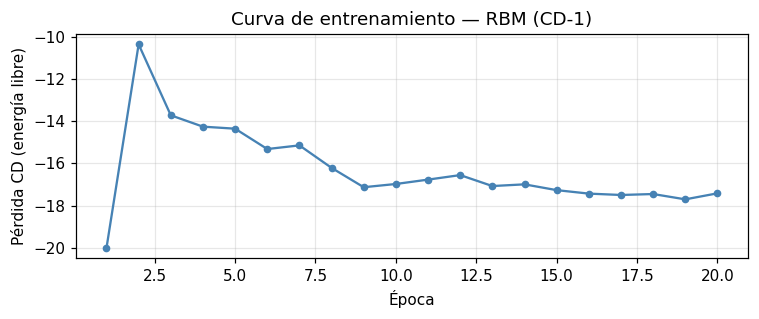

In [ ]:
# ── Plot training curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, EPOCHS_RBM + 1), rbm_losses, marker='o', markersize=4, color='steelblue')
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida CD (energía libre)')
ax.set_title('Curva de entrenamiento — RBM (CD-1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4️⃣ Visualización: filtros aprendidos y reconstrucciones

Cada fila de la matriz de pesos $W \in \mathbb{R}^{256 \times 784}$ puede interpretarse como un **filtro** o **detector de características**.
Al reformatear cada fila como imagen 28×28, observamos qué patrones activan cada unidad oculta.

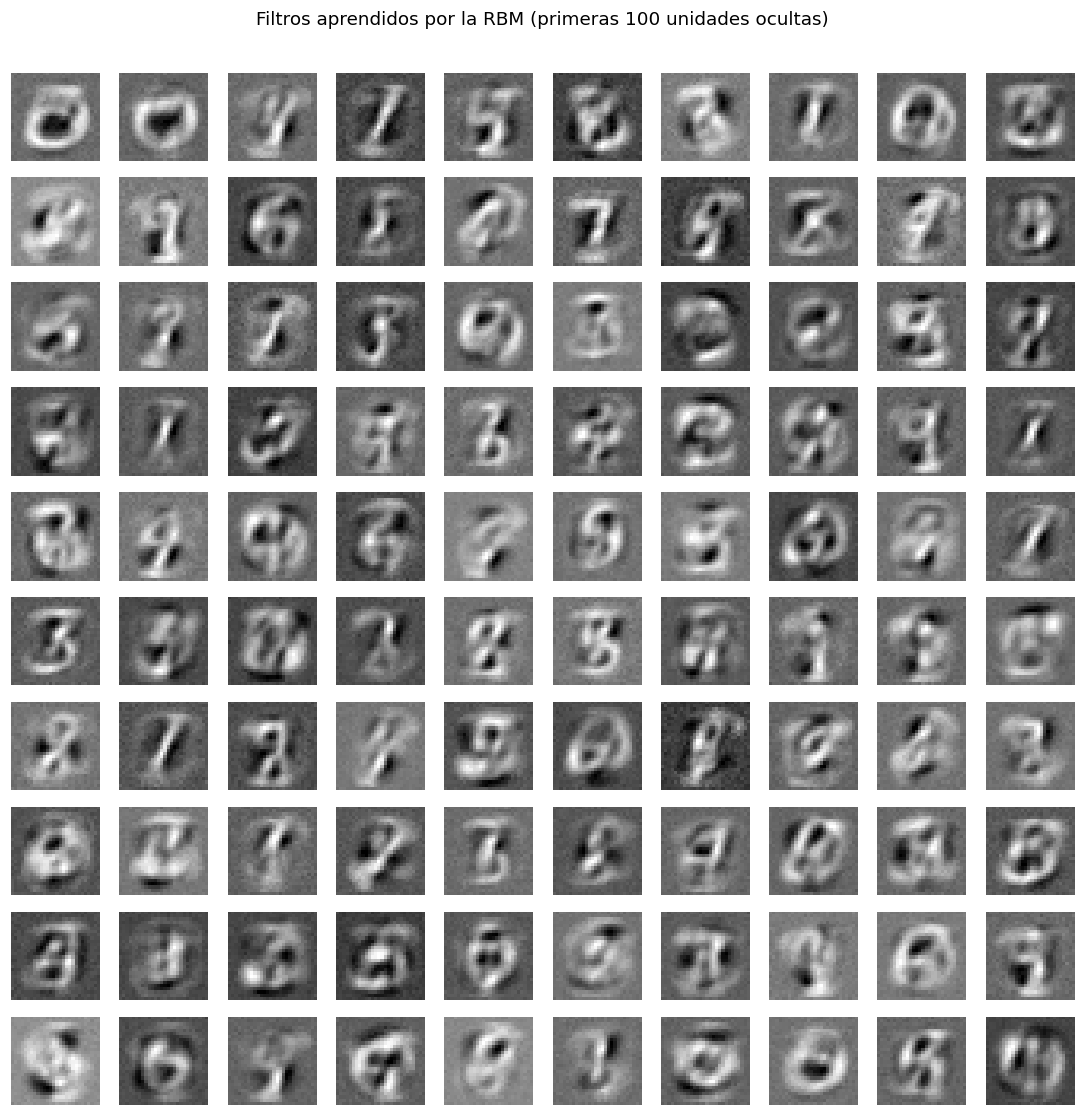

In [ ]:
# ── Visualize learned weight filters (first 100) ──────────────────────────
weights = rbm.W.data.cpu().numpy()   # (n_hidden, n_visible)

n_show = 100
n_cols = 10
n_rows = n_show // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
for idx, ax in enumerate(axes.flat):
    w = weights[idx].reshape(28, 28)
    # Normalize each filter independently for visibility
    w = (w - w.min()) / (w.max() - w.min() + 1e-8)
    ax.imshow(w, cmap='gray', interpolation='nearest')
    ax.axis('off')

fig.suptitle('Filtros aprendidos por la RBM (primeras 100 unidades ocultas)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

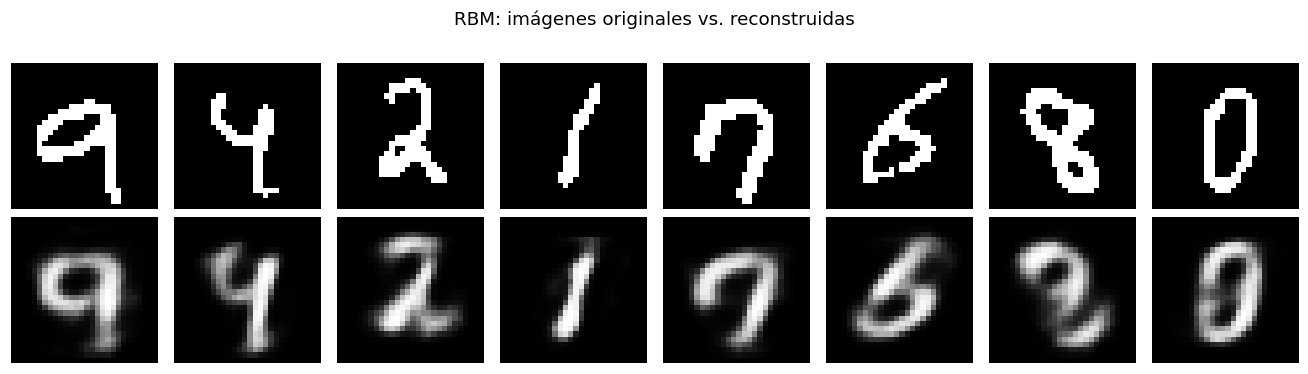

In [ ]:
# ── Show original vs reconstructed images ────────────────────────────────
rbm.eval()
test_batch, _ = next(iter(DataLoader(mnist_small, batch_size=8, shuffle=True)))
test_flat = test_batch.view(8, -1).to(DEVICE)

with torch.no_grad():
    reconstructed = rbm.reconstruct(test_flat).cpu().numpy()

originals = test_batch.numpy().reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(originals[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstrucción', fontsize=10)
fig.suptitle('RBM: imágenes originales vs. reconstruidas', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5️⃣ Máquina de Boltzmann Profunda (DBM) — Pre-entrenamiento

La `DBM` en `dbm_pyramidnet_models.py` implementa una DBM de 2 capas con **pre-entrenamiento greedy** siguiendo a Salakhutdinov & Hinton (2009).

### Procedimiento de pre-entrenamiento

```
Paso 1 — RBM-1 (modificada, entrada duplicada → pesos atados):
    v  ──W¹──→  h¹
    Aprende a comprimir los datos visibles.

Paso 2 — RBM-2 (modificada, capa oculta duplicada):
    h¹ ──W²──→  h²
    Aprende representaciones de orden superior.

Resultado:
    v ──W¹──→ h¹ ──W²──→ h²   (DBM inicializada)
```

In [ ]:
class DBM(nn.Module):
    """
    Two-layer Deep Boltzmann Machine (Salakhutdinov & Hinton, 2009).

    Architecture (all undirected):
        v  ←──W1──→  h1  ←──W2──→  h2

    Energy:
        E(v, h1, h2) = -v^T W1 h1 - h1^T W2 h2

    Training:
      1. Greedy layerwise pre-training with two modified RBMs:
           - Bottom RBM: input doubled (tied weights)   → initialises W1
           - Top    RBM: hidden layer doubled            → initialises W2
      2. Mean-field variational inference for reconstruction.

    Parameters
    ----------
    n_visible : int  – visible units (e.g. 784 for MNIST)
    n_hidden1 : int  – first hidden layer units
    n_hidden2 : int  – second hidden layer units
    k         : int  – CD steps for pre-training RBMs
    """

    def __init__(self, n_visible: int, n_hidden1: int, n_hidden2: int, k: int = 1):
        super().__init__()
        self.n_visible = n_visible
        self.n_hidden1 = n_hidden1
        self.n_hidden2 = n_hidden2
        self.k = k

        self.W1  = nn.Parameter(torch.randn(n_hidden1, n_visible)  * 0.01)
        self.W2  = nn.Parameter(torch.randn(n_hidden2, n_hidden1)  * 0.01)
        self.bv  = nn.Parameter(torch.zeros(n_visible))
        self.bh1 = nn.Parameter(torch.zeros(n_hidden1))
        self.bh2 = nn.Parameter(torch.zeros(n_hidden2))

        self.rbm1 = None
        self.rbm2 = None

    # ── Mean-field variational inference ──────────────────────────────────

    @torch.no_grad()
    def mean_field_h1(self, v, mu2):
        """mu1 = sigmoid(W1 v + W2^T mu2 + bh1)"""
        return torch.sigmoid(F.linear(v, self.W1, self.bh1) + F.linear(mu2, self.W2.t()))

    @torch.no_grad()
    def mean_field_h2(self, mu1):
        """mu2 = sigmoid(W2 mu1 + bh2)"""
        return torch.sigmoid(F.linear(mu1, self.W2, self.bh2))

    @torch.no_grad()
    def infer(self, v, n_iter=10):
        """
        Variational mean-field fixed-point iterations.
        Returns approximate posterior marginals (mu1, mu2).
        """
        mu1 = torch.sigmoid(F.linear(v, self.W1, self.bh1))
        mu2 = torch.sigmoid(F.linear(mu1, self.W2, self.bh2))
        for _ in range(n_iter):
            mu1 = self.mean_field_h1(v, mu2)
            mu2 = self.mean_field_h2(mu1)
        return mu1, mu2

    @torch.no_grad()
    def reconstruct(self, v, n_iter=5):
        """Approximate reconstruction: v → mean-field inference → v' via W1^T."""
        mu1, _ = self.infer(v, n_iter)
        return torch.sigmoid(F.linear(mu1, self.W1.t(), self.bv))

    # ── Greedy layerwise pre-training ─────────────────────────────────────

    def pretrain(self, data_loader, device,
                 epochs=25, lr=0.01, momentum=0.9, weight_decay=1e-4,
                 lr_decay_step=8, lr_decay_gamma=0.1, verbose=True):
        """
        Greedy layerwise pre-training (Salakhutdinov & Hinton, 2009).

        Uses SGD + momentum (same as original paper). Adam's adaptive LR
        amplifies the noisy CD-1 gradient estimates, causing the loss to
        drift upward after the initial improvement.

        Bottom RBM: input doubled (tied weights) — compensates for missing top-down.
        Top    RBM: hidden units doubled         — compensates for missing bottom-up.
        After composing, the DBM conditional distributions match exactly (Eq. 19).
        """
        history = {"rbm1_loss": [], "rbm2_loss": []}

        def _make_opt_sched(params):
            opt   = torch.optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
            sched = torch.optim.lr_scheduler.StepLR(opt, step_size=lr_decay_step, gamma=lr_decay_gamma)
            return opt, sched

        # ── Step 1: bottom RBM (v → h1) ───────────────────────────────────
        rbm1 = RBM(self.n_visible, self.n_hidden1, k=self.k).to(device)
        opt1, sched1 = _make_opt_sched(rbm1.parameters())
        if verbose: print("Pre-training: RBM-1 (visible → h¹) …")
        for ep in range(epochs):
            ep_loss, nb = 0.0, 0
            for (x, _) in data_loader:
                x = x.view(x.size(0), -1).to(device)
                loss = rbm1(x)          # CD loss on original input
                opt1.zero_grad(); loss.backward(); opt1.step()
                ep_loss += loss.item(); nb += 1
            avg = ep_loss / nb
            history["rbm1_loss"].append(avg)
            sched1.step()
            if verbose and (ep + 1) % max(1, epochs // 5) == 0:
                print(f"  Época {ep+1}/{epochs}  pérdida CD = {avg:.4f}  lr = {sched1.get_last_lr()[0]:.6f}")

        self.rbm1 = rbm1
        with torch.no_grad():
            self.W1.copy_(rbm1.W); self.bh1.copy_(rbm1.c); self.bv.copy_(rbm1.b)

        # ── Step 2: top RBM (h1 → h2) ─────────────────────────────────────
        rbm2 = RBM(self.n_hidden1, self.n_hidden2, k=self.k).to(device)
        opt2, sched2 = _make_opt_sched(rbm2.parameters())
        if verbose: print("Pre-training: RBM-2 (h¹ → h²) …")
        for ep in range(epochs):
            ep_loss, nb = 0.0, 0
            for (x, _) in data_loader:
                x = x.view(x.size(0), -1).to(device)
                with torch.no_grad():
                    h1 = torch.bernoulli(rbm1.p_h_given_v(x))
                loss = rbm2(h1)
                opt2.zero_grad(); loss.backward(); opt2.step()
                ep_loss += loss.item(); nb += 1
            avg = ep_loss / nb
            history["rbm2_loss"].append(avg)
            sched2.step()
            if verbose and (ep + 1) % max(1, epochs // 5) == 0:
                print(f"  Época {ep+1}/{epochs}  pérdida CD = {avg:.4f}  lr = {sched2.get_last_lr()[0]:.6f}")

        self.rbm2 = rbm2
        with torch.no_grad():
            self.W2.copy_(rbm2.W); self.bh2.copy_(rbm2.c)

        if verbose: print("Pre-entrenamiento completado ✓")
        return history

print("DBM — definida ✓")

DBM — definida ✓


In [ ]:
# ── Build and pretrain a 2-layer DBM ─────────────────────────────────────
# 25 epochs gives the RBM-2 (h¹→h²) enough time to stabilize despite the
# extra noise from stochastic h¹ activations used as input.
N_H1 = 256   # units in hidden layer 1
N_H2 = 128   # units in hidden layer 2
EPOCHS_DBM = 25

dbm = DBM(n_visible=784, n_hidden1=N_H1, n_hidden2=N_H2, k=1).to(DEVICE)
print(f'DBM: 784 → {N_H1} → {N_H2}')
print(f'Parámetros totales: {sum(p.numel() for p in dbm.parameters()):,}')

history_dbm = dbm.pretrain(
    data_loader=loader_rbm,
    device=DEVICE,
    epochs=EPOCHS_DBM,
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
    lr_decay_step=8,
    lr_decay_gamma=0.1,
    verbose=True,
)

DBM: 784 → 256 → 128
Parámetros totales: 234,640
Pre-training: RBM-1 (visible → h¹) …
  Época 5/25  pérdida CD = -14.2643  lr = 0.010000
  Época 10/25  pérdida CD = -16.8380  lr = 0.001000
  Época 15/25  pérdida CD = -16.6329  lr = 0.001000
  Época 20/25  pérdida CD = -17.4330  lr = 0.000100
  Época 25/25  pérdida CD = -17.2058  lr = 0.000010
Pre-training: RBM-2 (h¹ → h²) …
  Época 5/25  pérdida CD = -7.8569  lr = 0.010000
  Época 10/25  pérdida CD = -7.8489  lr = 0.001000
  Época 15/25  pérdida CD = -7.7983  lr = 0.001000
  Época 20/25  pérdida CD = -7.8104  lr = 0.000100
  Época 25/25  pérdida CD = -7.8613  lr = 0.000010
Pre-entrenamiento completado ✓


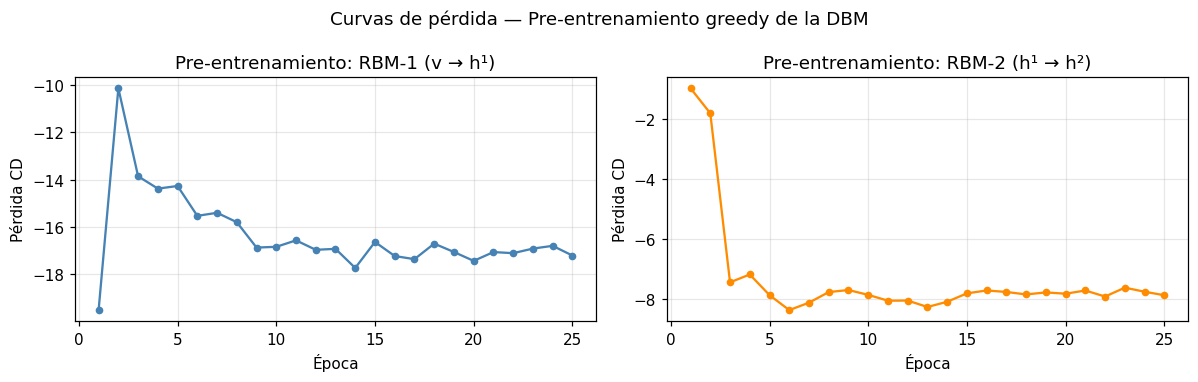

In [ ]:
# ── Plot pre-training curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, key, label, color in zip(
    axes,
    ['rbm1_loss', 'rbm2_loss'],
    ['RBM-1 (v → h¹)', 'RBM-2 (h¹ → h²)'],
    ['steelblue', 'darkorange'],
):
    ax.plot(range(1, EPOCHS_DBM + 1), history_dbm[key],
            marker='o', markersize=4, color=color)
    ax.set_title(f'Pre-entrenamiento: {label}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida CD')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de pérdida — Pre-entrenamiento greedy de la DBM', fontsize=12)
plt.tight_layout()
plt.show()

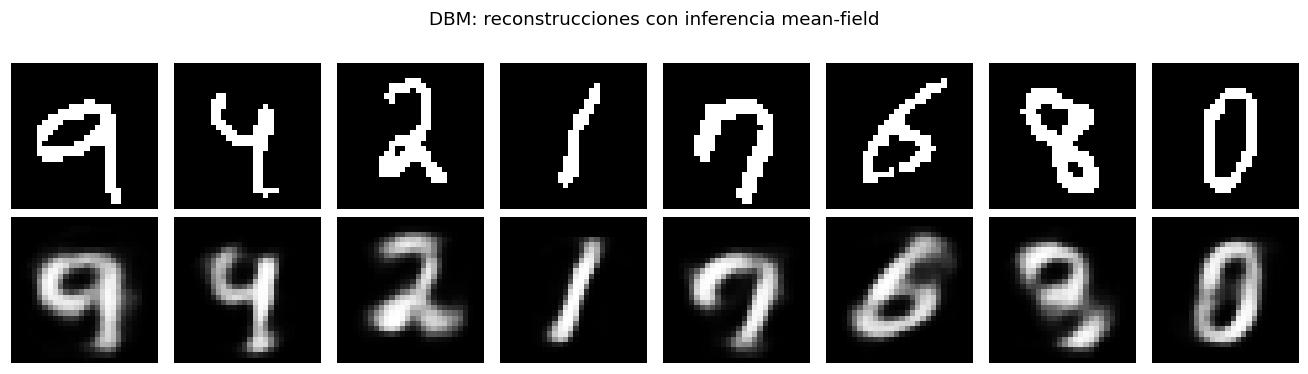

In [ ]:
# ── DBM reconstruction (using mean-field inference) ───────────────────────
dbm.eval()
test_flat_dbm = test_flat  # same test batch used for RBM

with torch.no_grad():
    rec_dbm = dbm.reconstruct(test_flat_dbm, n_iter=10).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(originals[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(rec_dbm[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstr. DBM', fontsize=10)
fig.suptitle('DBM: reconstrucciones con inferencia mean-field', fontsize=12)
plt.tight_layout()
plt.show()

---
## 6️⃣ Experimento Interactivo — RBM: número de unidades ocultas

### ¿Qué exploraremos?

El número de unidades ocultas $P$ controla la **capacidad representacional** de la RBM:

| Valor de $P$ | Comportamiento |
|---|---|
| **$P$ pequeño** (< 64) | Representación comprimida, reconstrucción difusa |
| **$P$ óptimo** (~256) | Buena reconstrucción sin sobreajuste |
| **$P$ grande** (> 512) | Alta capacidad, riesgo de memorización |

Ajusta el deslizador y observa cómo cambia la calidad de reconstrucción.

In [ ]:
# Pre-compute a fixed test sample for interactive comparison
_fixed_batch, _ = next(iter(DataLoader(mnist_small, batch_size=6, shuffle=True)))
_fixed_flat = _fixed_batch.view(6, -1).to(DEVICE)
_fixed_orig = _fixed_batch.numpy().reshape(-1, 28, 28)

def train_and_show_rbm(n_hidden_val):
    """Train a small RBM with n_hidden units for 5 epochs and show reconstructions."""
    rbm_exp = RBM(n_visible=784, n_hidden=n_hidden_val, k=1).to(DEVICE)
    # SGD+momentum: stable CD training without the drift caused by Adam
    opt = optim.SGD(rbm_exp.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    sched = optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    rbm_exp.train()
    for _ in range(5):
        for (x, _) in loader_rbm:
            x = x.view(x.size(0), -1).to(DEVICE)
            loss = rbm_exp(x)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

    rbm_exp.eval()
    with torch.no_grad():
        rec = rbm_exp.reconstruct(_fixed_flat).cpu().numpy()

    # MSE between original and reconstruction
    mse = np.mean((_fixed_orig - rec.reshape(-1, 28, 28)) ** 2)

    fig, axes = plt.subplots(2, 6, figsize=(11, 4))
    fig.suptitle(f'RBM con {n_hidden_val} unidades ocultas  |  MSE = {mse:.4f}',
                 fontsize=12)
    for i in range(6):
        axes[0, i].imshow(_fixed_orig[i], cmap='gray'); axes[0, i].axis('off')
        axes[1, i].imshow(rec[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Reconstr.', fontsize=9)
    plt.tight_layout()
    plt.show()


# ── Widgets ───────────────────────────────────────────────────────────────
# Note: 'out_rbm' avoids collision with the variable 'out' used later in the
# PyramidNet training cell (out = pnet(imgs)), which would shadow this widget
# and cause AttributeError: __enter__ when the button callback is triggered.
slider_hidden = widgets.IntSlider(
    value=128, min=16, max=512, step=16,
    description='Unidades ocultas P:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%'),
)
btn_run = widgets.Button(
    description='▶ Entrenar y visualizar',
    button_style='primary',
    layout=widgets.Layout(width='220px'),
)
out_rbm = widgets.Output()

def on_click(_):
    out_rbm.clear_output(wait=True)   # clear before entering context
    with out_rbm:
        print(f'Entrenando RBM con P={slider_hidden.value} (5 épocas)…')
        train_and_show_rbm(slider_hidden.value)

btn_run.on_click(on_click)
display(widgets.VBox([slider_hidden, btn_run, out_rbm]))

---
## 7️⃣ Análisis: MSE de reconstrucción vs número de unidades ocultas

P=  16  →  MSE = 0.07283
P=  32  →  MSE = 0.06695
P=  64  →  MSE = 0.05731
P= 128  →  MSE = 0.05281
P= 256  →  MSE = 0.05092
P= 384  →  MSE = 0.05109
P= 512  →  MSE = 0.05015


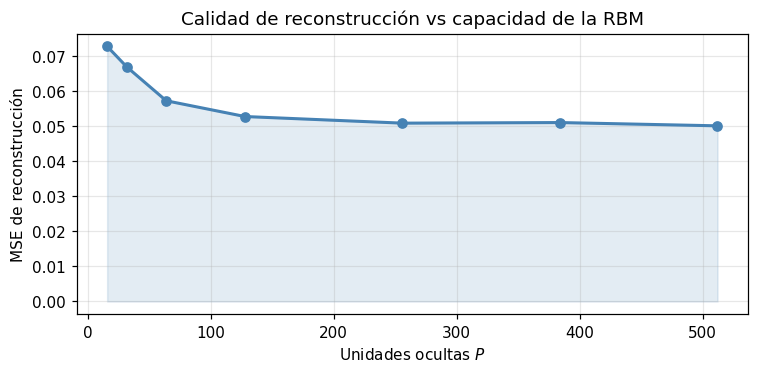

In [ ]:
# ── Sweep over different hidden unit counts ───────────────────────────────
hidden_sizes = [16, 32, 64, 128, 256, 384, 512]
mse_scores = []

for nh in hidden_sizes:
    rbm_s = RBM(n_visible=784, n_hidden=nh, k=1).to(DEVICE)
    opt_s = optim.SGD(rbm_s.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    sched_s = optim.lr_scheduler.StepLR(opt_s, step_size=2, gamma=0.5)
    rbm_s.train()
    for _ in range(5):
        for (x, _) in loader_rbm:
            x = x.view(x.size(0), -1).to(DEVICE)
            loss = rbm_s(x)
            opt_s.zero_grad(); loss.backward(); opt_s.step()
        sched_s.step()
    rbm_s.eval()
    with torch.no_grad():
        rec_s = rbm_s.reconstruct(_fixed_flat).cpu().numpy()
    mse_val = float(np.mean((_fixed_orig - rec_s.reshape(-1, 28, 28)) ** 2))
    mse_scores.append(mse_val)
    print(f'P={nh:4d}  →  MSE = {mse_val:.5f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hidden_sizes, mse_scores, marker='o', color='steelblue', linewidth=2)
ax.fill_between(hidden_sizes, mse_scores, alpha=0.15, color='steelblue')
ax.set_xlabel('Unidades ocultas $P$')
ax.set_ylabel('MSE de reconstrucción')
ax.set_title('Calidad de reconstrucción vs capacidad de la RBM')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📝 Resumen — Máquinas de Boltzmann Profundas

| Concepto | Lo que aprendimos |
|---|---|
| **BM general** | Energía $E(v,h)$ define una distribución conjunta; aprendizaje intractable |
| **RBM** | Sin conexiones intra-capa → inferencia exacta con Gibbs por bloques |
| **CD-k** | Aproxima el gradiente del log-likelihood corriendo $k$ pasos de Gibbs desde los datos |
| **DBM** | Múltiples capas ocultas, completamente no-dirigida → jerarquía de características |
| **Pre-entrenamiento** | RBMs modificadas (entrada/ocultos duplicados) inicializan bien los pesos |
| **Mean-field** | Inferencia variacional factorial aproxima $p(h|v)$ con punto fijo iterativo |
| **Capacidad** | Más unidades ocultas $P$ → menor MSE de reconstrucción (hasta cierto límite) |

### Ventajas de las DBMs
* Modelos **generativos**: pueden generar nuevas muestras plausibles.
* **Aprendizaje no supervisado**: no requieren etiquetas.
* La inferencia incorpora retroalimentación **top-down + bottom-up**.
* Excelente inicialización para redes discriminativas (fine-tuning con backprop).


---
---
# PARTE II — PyramidNet

## Introducción

### El éxito de ResNet

En 2015, He et al. introdujeron las **Redes Residuales** (*ResNet*), que resolvieron el problema de degradación del gradiente en redes muy profundas mediante conexiones de salto (*skip connections*):

$$
y = \mathcal{F}(x, \{W_i\}) + x
$$

La salida $y$ es la suma del **residuo aprendido** $\mathcal{F}(x)$ más la entrada original $x$. Si el residuo es cero, la capa se convierte en identidad, facilitando el entrenamiento profundo.

### El problema con ResNet: aumento brusco de canales

En ResNet original, el número de mapas de características (canales) se **duplica abruptamente** en los puntos de submuestreo (*downsampling*):

```
ResNet-110:
Conv inicial: 16 canales
Grupo 1: ─────────────────── 16 canales (18 bloques)
                              ↓ ×2  ← Salto brusco
Grupo 2: ─────────────────── 32 canales (18 bloques)
                              ↓ ×2
Grupo 3: ─────────────────── 64 canales (18 bloques)
```

**¿Por qué es un problema?** La mayor parte de los parámetros se concentra en el último grupo, creando un cuello de botella en el aprendizaje.

### La solución PyramidNet: crecimiento gradual

Han et al. (CVPR 2017) proponen aumentar los canales **gradualmente en cada bloque residual**, formando una pirámide:

```
PyramidNet-110 (α=48):
Conv inicial: 16 canales
Bloque 1:  17 canales
Bloque 2:  17 canales
   ...
Bloque 54: 63 canales
   ...
Bloque 108: 64 canales → 64+α = 64+48 = ... ≈ 64 total
```


---
## Conceptos Clave — PyramidNet

### 8.1 Programación de canales (*channel schedule*)

Sea $N$ el número total de bloques residuales y $D_0 = 16$ la dimensión inicial.

**Additive PyramidNet** (mejor rendimiento):

$$
D_k = D_0 + \left\lfloor \frac{\alpha \cdot k}{N} \right\rfloor, \quad k = 1, 2, \ldots, N
$$

**Multiplicative PyramidNet**:

$$
D_k = D_0 \cdot \left\lfloor \alpha^{k/N} \right\rfloor
$$

donde $\alpha$ es el **factor de ensanchamiento** (*widening factor*): controla cuánto crecen los canales en total.

### 8.2 Conexión de salto con *zero-padding*

Como el número de canales cambia en cada bloque, la conexión de salto necesita adaptar dimensiones. Se usa **zero-padding** (rellenar con ceros) en lugar de proyecciones costosas:

$$
\text{shortcut}(x) = \text{AvgPool}(x) \;\|\; \mathbf{0}_{\Delta C}
$$

donde $\Delta C = D_k - D_{k-1}$ canales extras se rellenan con cero.

### 8.3 Nuevas posiciones de BN y ReLU

PyramidNet también propone modificar el orden de las operaciones dentro del bloque residual:

| Arquitectura | Orden |
|---|---|
| ResNet original | Conv → BN → ReLU → Conv → BN → ReLU |
| Pre-Activation ResNet | BN → ReLU → Conv → BN → ReLU → Conv |
| **PyramidNet** | **BN → Conv → BN → ReLU → Conv → BN** |

**Cambios clave**:
* Se **elimina el primer ReLU** (mejora estabilidad).
* Se **añade un BN después del último Conv** (normaliza antes de la suma con el shortcut).

### 8.4 Glosario

| Símbolo | Significado |
|---|---|
| $D_k$ | Número de canales en el bloque $k$ |
| $D_0$ | Canales iniciales (16 para CIFAR) |
| $\alpha$ | Factor de ensanchamiento total |
| $N$ | Número total de bloques residuales |
| $n$ | Bloques por grupo (3 grupos para CIFAR) |
| BN | Batch Normalization |
| ReLU | Rectified Linear Unit |


---
## 8️⃣ Implementación de PyramidNet

La clase `PyramidNet` (en `dbm_pyramidnet_models.py`) implementa el modelo completo con la programación aditiva de canales.

### Estructura del bloque básico (`PyramidBasicBlock`)

```
entrada x
   │
   ├─── BN₀ ─→ Conv(3×3) ─→ BN₁ ─→ ReLU ─→ Conv(3×3) ─→ BN₂ ─┐
   │                                                              ↓
   └─── AvgPool (si stride>1) ──→ ZeroPad (si ΔC>0) ────────── (+)
                                                                  │
                                                              salida y
```

In [ ]:
class PyramidBasicBlock(nn.Module):
    """
    Pyramid basic residual block: BN → Conv → BN → ReLU → Conv → BN.

    Compared to Pre-Activation ResNet:
      - First ReLU removed (stabilizes gradients)
      - Extra BN after the last Conv (before skip connection)

    The shortcut uses zero-padding when in_channels != out_channels.
    Stride=2 is applied at the first Conv for spatial downsampling.
    """

    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels

    def forward(self, x):
        shortcut = x
        out = self.bn0(x)
        out = self.conv1(out)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.stride != 1:
            shortcut = F.avg_pool2d(shortcut, kernel_size=2, stride=self.stride, ceil_mode=True)
        if self.in_channels != self.out_channels:
            pad_size = self.out_channels - self.in_channels
            shortcut = F.pad(shortcut, (0, 0, 0, 0, 0, pad_size))
        return out + shortcut


class PyramidBottleneckBlock(nn.Module):
    """
    Pyramid bottleneck residual block.
    BN → Conv1×1 → BN → ReLU → Conv3×3 → BN → ReLU → Conv1×1 → BN.
    expansion = 4: effective output channels = out_channels * 4.
    """

    expansion = 4

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        bottleneck = out_channels
        expanded   = out_channels * self.expansion

        self.bn0   = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, bottleneck, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(bottleneck)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(bottleneck, bottleneck, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(bottleneck)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(bottleneck, expanded, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(expanded)

        self.stride      = stride
        self.in_channels = in_channels
        self.out_channels = expanded

    def forward(self, x):
        shortcut = x
        out = self.bn0(x)
        out = self.conv1(out); out = self.bn1(out); out = self.relu1(out)
        out = self.conv2(out); out = self.bn2(out); out = self.relu2(out)
        out = self.conv3(out); out = self.bn3(out)
        if self.stride != 1:
            shortcut = F.avg_pool2d(shortcut, kernel_size=2, stride=self.stride, ceil_mode=True)
        if self.in_channels != self.out_channels:
            shortcut = F.pad(shortcut, (0, 0, 0, 0, 0, self.out_channels - self.in_channels))
        return out + shortcut


class PyramidNet(nn.Module):
    """
    PyramidNet — Deep Pyramidal Residual Networks (Han et al., CVPR 2017).

    Additive channel schedule:
        D_k = D_0 + floor(alpha * k / N),   k = 1 … N
    where alpha is the widening factor and N the total number of residual units.

    Parameters
    ----------
    depth      : int  – network depth
    alpha      : int  – widening factor
    num_classes: int  – output classes
    block_type : str  – 'basic' or 'bottleneck'
    dataset    : str  – 'cifar10', 'cifar100', or 'imagenet'
    """

    def __init__(self, depth=110, alpha=48, num_classes=10,
                 block_type="basic", dataset="cifar10"):
        super().__init__()
        self.dataset = dataset

        if block_type == "bottleneck":
            block = PyramidBottleneckBlock
            units_per_group = (depth - 2) // 9
        else:
            block = PyramidBasicBlock
            units_per_group = (depth - 2) // 6

        n_units = units_per_group * 3
        D0 = 16

        # Additive channel schedule: D_k = D_0 + floor(alpha * k / N)
        self.channel_schedule = [
            D0 + math.floor(alpha * k / n_units) for k in range(1, n_units + 1)
        ]

        # Initial convolution
        if dataset == "imagenet":
            self.conv_init = nn.Sequential(
                nn.Conv2d(3, D0, 7, stride=2, padding=3, bias=False),
                nn.BatchNorm2d(D0), nn.ReLU(inplace=True),
                nn.MaxPool2d(3, stride=2, padding=1),
            )
        else:
            self.conv_init = nn.Sequential(
                nn.Conv2d(3, D0, 3, padding=1, bias=False),
                nn.BatchNorm2d(D0),
            )

        # Build three groups of residual units
        layers, in_ch = [], D0
        for group in range(3):
            for unit in range(units_per_group):
                idx    = group * units_per_group + unit
                out_ch = self.channel_schedule[idx]
                stride = 2 if (unit == 0 and group > 0) else 1
                layers.append(block(in_ch, out_ch, stride=stride))
                in_ch = out_ch * block.expansion if block_type == "bottleneck" else out_ch

        self.layers    = nn.Sequential(*layers)
        self.bn_final  = nn.BatchNorm2d(in_ch)
        self.relu_final = nn.ReLU(inplace=True)
        self.avgpool   = nn.AdaptiveAvgPool2d(1)
        self.fc        = nn.Linear(in_ch, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv_init(x)
        x = self.layers(x)
        x = self.bn_final(x)
        x = self.relu_final(x)
        x = self.avgpool(x)
        return self.fc(x.view(x.size(0), -1))

    def channel_widths(self):
        """Return the channel width at each residual unit (additive schedule)."""
        return self.channel_schedule


def build_pyramidnet_cifar(depth=20, alpha=48, num_classes=10):
    """Convenience builder for CIFAR experiments."""
    return PyramidNet(depth=depth, alpha=alpha, num_classes=num_classes,
                      block_type="basic", dataset="cifar10")

print("PyramidBasicBlock, PyramidBottleneckBlock, PyramidNet, build_pyramidnet_cifar — definidos ✓")

PyramidBasicBlock, PyramidBottleneckBlock, PyramidNet, build_pyramidnet_cifar — definidos ✓


In [ ]:
# ── Build a small PyramidNet and inspect its channel schedule ─────────────
pyramid_demo = build_pyramidnet_cifar(depth=20, alpha=48, num_classes=10)

print('Arquitectura PyramidNet (depth=20, α=48):')
print(f'  Bloques residuales totales: {len(pyramid_demo.channel_widths())}')
print(f'  Canales por bloque: {pyramid_demo.channel_widths()}')
print(f'  Total de parámetros: {sum(p.numel() for p in pyramid_demo.parameters()):,}')

Arquitectura PyramidNet (depth=20, α=48):
  Bloques residuales totales: 9
  Canales por bloque: [21, 26, 32, 37, 42, 48, 53, 58, 64]
  Total de parámetros: 306,237


---
## 9️⃣ Visualización de la arquitectura — Crecimiento de canales

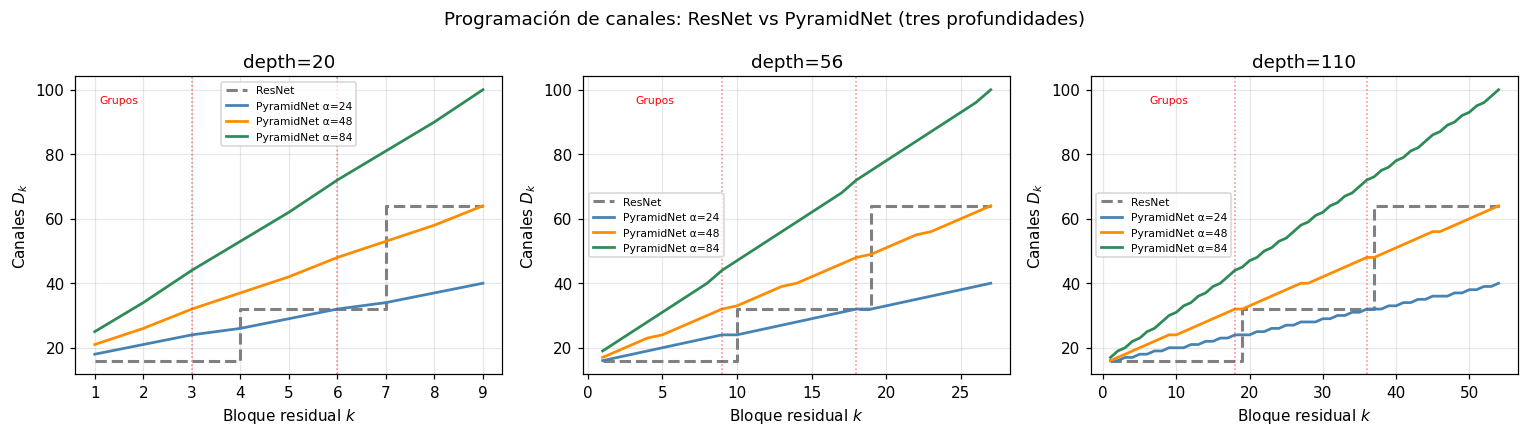

In [ ]:
# ── Plot channel width schedule for PyramidNet vs ResNet ─────────────────
def resnet_schedule(depth=20, D0=16):
    """ResNet: channels double at group boundaries (3 groups)."""
    n_per_group = (depth - 2) // 6
    schedule = []
    for g, ch in enumerate([D0, D0*2, D0*4]):
        schedule.extend([ch] * n_per_group)
    return schedule

def pyramidnet_schedule(depth=20, alpha=48, D0=16):
    n = (depth - 2) // 6 * 3
    return [D0 + math.floor(alpha * k / n) for k in range(1, n + 1)]


alphas_compare = [24, 48, 84]
depths = [20, 56, 110]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, depth in zip(axes, depths):
    rs = resnet_schedule(depth)
    blocks = list(range(1, len(rs) + 1))
    ax.step(blocks, rs, where='post', color='gray', linewidth=2,
            label='ResNet', linestyle='--')

    colors = ['steelblue', 'darkorange', 'seagreen']
    for alpha_val, color in zip(alphas_compare, colors):
        ps = pyramidnet_schedule(depth, alpha_val)
        ax.plot(blocks, ps, color=color, linewidth=1.8,
                label=f'PyramidNet α={alpha_val}')

    n_per_g = (depth - 2) // 6
    for sep in [n_per_g, 2 * n_per_g]:
        ax.axvline(sep, color='red', linestyle=':', alpha=0.5, linewidth=1)

    ax.set_title(f'depth={depth}')
    ax.set_xlabel('Bloque residual $k$')
    ax.set_ylabel('Canales $D_k$')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.annotate('Grupos', xy=(n_per_g / 2, ax.get_ylim()[1] * 0.92),
                ha='center', fontsize=7, color='red')

fig.suptitle('Programación de canales: ResNet vs PyramidNet (tres profundidades)',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔟 Entrenamiento en CIFAR-10 — Demo rápido

Entrenamos un **PyramidNet pequeño** (depth=20, α=48) en CIFAR-10 para demostrar el flujo completo de entrenamiento.

In [ ]:
# ── CIFAR-10 data loaders ─────────────────────────────────────────────────
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD  = [0.2023, 0.1994, 0.2010]

transform_train_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
transform_test_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train_cifar)
cifar_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test_cifar)

# Use a small subset for fast demo
train_idx = torch.randperm(len(cifar_train))[:4000]
test_idx  = torch.randperm(len(cifar_test))[:1000]
loader_train_c10 = DataLoader(Subset(cifar_train, train_idx), batch_size=128, shuffle=True)
loader_test_c10  = DataLoader(Subset(cifar_test, test_idx),  batch_size=128, shuffle=False)

CLASSES_CIFAR = ['avión','automóvil','pájaro','gato','ciervo',
                 'perro','rana','caballo','barco','camión']
print(f'CIFAR-10 — entrenamiento: {len(train_idx)} | prueba: {len(test_idx)}')

CIFAR-10 — entrenamiento: 4000 | prueba: 1000


In [ ]:
# ── Build and train PyramidNet-20 ─────────────────────────────────────────
EPOCHS_CIFAR = 15

pnet = build_pyramidnet_cifar(depth=20, alpha=48, num_classes=10).to(DEVICE)
print(f'PyramidNet-20 (α=48)  →  {sum(p.numel() for p in pnet.parameters()):,} parámetros')

criterion_c10 = nn.CrossEntropyLoss()
optimizer_c10 = optim.SGD(pnet.parameters(), lr=0.1, momentum=0.9,
                          nesterov=True, weight_decay=5e-4)
scheduler_c10 = optim.lr_scheduler.CosineAnnealingLR(optimizer_c10, T_max=EPOCHS_CIFAR)

train_losses, train_accs, test_accs = [], [], []

for epoch in range(EPOCHS_CIFAR):
    # --- Training ---
    pnet.train()
    ep_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader_train_c10:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_c10.zero_grad()
        out = pnet(imgs)
        loss = criterion_c10(out, labels)
        loss.backward()
        optimizer_c10.step()
        ep_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    scheduler_c10.step()
    train_losses.append(ep_loss / len(loader_train_c10))
    train_accs.append(correct / total * 100)

    # --- Evaluation ---
    pnet.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for imgs, labels in loader_test_c10:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = pnet(imgs)
            correct_t += (out.argmax(1) == labels).sum().item()
            total_t += labels.size(0)
    test_accs.append(correct_t / total_t * 100)

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Época {epoch+1:2d}/{EPOCHS_CIFAR}  '
              f'Pérdida={train_losses[-1]:.3f}  '
              f'Acc_entren={train_accs[-1]:.1f}%  '
              f'Acc_prueba={test_accs[-1]:.1f}%')

print(f'\nMejor Acc prueba: {max(test_accs):.1f}%')

PyramidNet-20 (α=48)  →  306,237 parámetros
Época  1/15  Pérdida=2.077  Acc_entren=21.2%  Acc_prueba=12.1%
Época  3/15  Pérdida=1.686  Acc_entren=34.6%  Acc_prueba=38.9%
Época  6/15  Pérdida=1.442  Acc_entren=44.7%  Acc_prueba=39.0%
Época  9/15  Pérdida=1.166  Acc_entren=57.7%  Acc_prueba=54.3%
Época 12/15  Pérdida=1.000  Acc_entren=63.4%  Acc_prueba=57.8%
Época 15/15  Pérdida=0.880  Acc_entren=69.2%  Acc_prueba=63.1%

Mejor Acc prueba: 63.1%


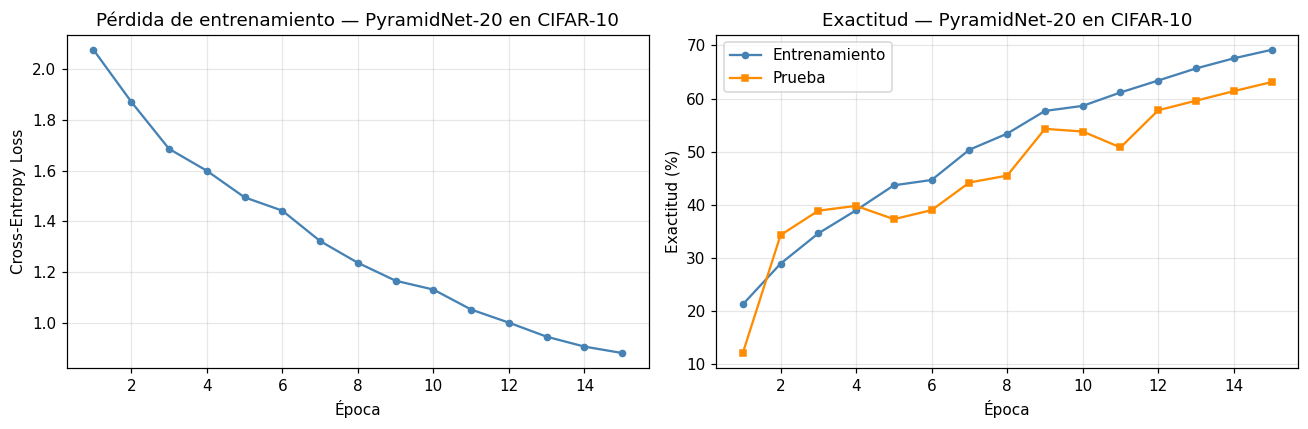

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────
epochs_range = range(1, EPOCHS_CIFAR + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, marker='o', markersize=4, color='steelblue')
axes[0].set_title('Pérdida de entrenamiento — PyramidNet-20 en CIFAR-10')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accs, marker='o', markersize=4,
             color='steelblue', label='Entrenamiento')
axes[1].plot(epochs_range, test_accs, marker='s', markersize=4,
             color='darkorange', label='Prueba')
axes[1].set_title('Exactitud — PyramidNet-20 en CIFAR-10')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Exactitud (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

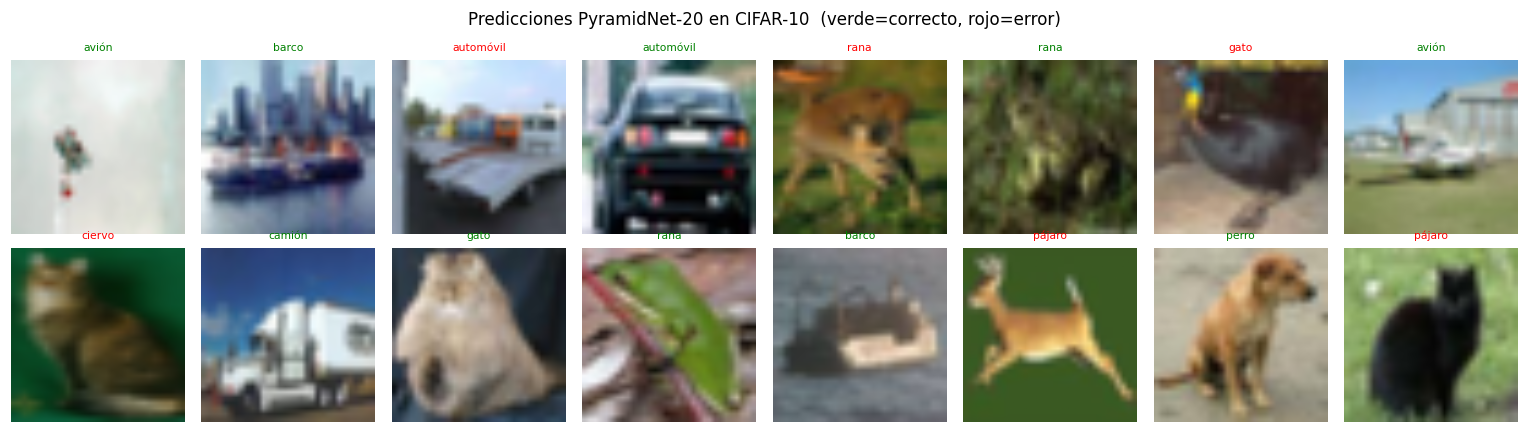

In [ ]:
# ── Show some prediction examples ─────────────────────────────────────────
pnet.eval()
sample_imgs, sample_labels = next(iter(DataLoader(
    Subset(cifar_test, test_idx[:16]), batch_size=16, shuffle=False)))

with torch.no_grad():
    preds = pnet(sample_imgs.to(DEVICE)).argmax(1).cpu()

# Denormalize for display
mean_t = torch.tensor(CIFAR_MEAN).view(3,1,1)
std_t  = torch.tensor(CIFAR_STD).view(3,1,1)
imgs_show = (sample_imgs * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = imgs_show[i].permute(1, 2, 0).numpy()
    ax.imshow(img, interpolation='bilinear')
    correct_pred = preds[i] == sample_labels[i]
    color = 'green' if correct_pred else 'red'
    ax.set_title(f'{CLASSES_CIFAR[preds[i]]}', fontsize=7, color=color)
    ax.axis('off')

fig.suptitle('Predicciones PyramidNet-20 en CIFAR-10  (verde=correcto, rojo=error)',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Experimento Interactivo — Efecto del factor α

### ¿Qué exploraremos?

El factor $\alpha$ controla cuánto crecen los canales a lo largo de la red:

| $\alpha$ | Comportamiento |
|---|---|
| **Pequeño** (< 24) | Pocos canales, modelo ligero, menor capacidad |
| **Medio** (48–84) | Balance entre capacidad y costo computacional |
| **Grande** (> 200) | Alta capacidad, millones de parámetros, mejor accuracy |

Ajusta el deslizador para visualizar la pirámide de canales y el conteo de parámetros.

In [ ]:
# ── Interactive alpha explorer ────────────────────────────────────────────
out_alpha = widgets.Output()

slider_alpha = widgets.IntSlider(
    value=48, min=6, max=200, step=6,
    description='α (widening):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='65%'),
)
slider_depth = widgets.Dropdown(
    options=[20, 56, 110],
    value=20,
    description='depth:',
    layout=widgets.Layout(width='30%'),
)

def update_alpha_plot(alpha_val, depth_val):
    schedule = pyramidnet_schedule(depth_val, alpha_val)
    resnet_sch = resnet_schedule(depth_val)
    blocks = list(range(1, len(schedule) + 1))

    n_per_g = (depth_val - 2) // 6

    # Count parameters (approximate, using channel schedule)
    model_tmp = build_pyramidnet_cifar(depth=depth_val, alpha=alpha_val)
    n_params = sum(p.numel() for p in model_tmp.parameters())

    with out_alpha:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Left: channel schedule
        axes[0].step(blocks, resnet_sch, where='post', color='gray',
                     linewidth=2, linestyle='--', label='ResNet')
        axes[0].plot(blocks, schedule, color='steelblue', linewidth=2.5,
                     label=f'PyramidNet α={alpha_val}')
        for sep in [n_per_g, 2 * n_per_g]:
            axes[0].axvline(sep, color='red', linestyle=':', alpha=0.5)
        axes[0].fill_between(blocks, schedule, alpha=0.15, color='steelblue')
        axes[0].set_xlabel('Bloque residual $k$')
        axes[0].set_ylabel('Canales $D_k$')
        axes[0].set_title(f'Pirámide de canales (depth={depth_val}, α={alpha_val})')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3)

        # Right: parameter count vs alpha
        alphas_sweep = list(range(6, 201, 6))
        param_counts = []
        for a in alphas_sweep:
            m = build_pyramidnet_cifar(depth=depth_val, alpha=a)
            param_counts.append(sum(p.numel() for p in m.parameters()) / 1e6)

        axes[1].plot(alphas_sweep, param_counts, color='darkorange', linewidth=2)
        axes[1].axvline(alpha_val, color='steelblue', linestyle='--', linewidth=2,
                        label=f'α={alpha_val} ({n_params/1e6:.2f}M params)')
        axes[1].set_xlabel('Factor de ensanchamiento α')
        axes[1].set_ylabel('Millones de parámetros')
        axes[1].set_title(f'Parámetros vs α (depth={depth_val})')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(f'PyramidNet-{depth_val} (α={alpha_val}): {n_params:,} parámetros = {n_params/1e6:.3f}M')

interactive_alpha = widgets.interactive(
    update_alpha_plot,
    alpha_val=slider_alpha,
    depth_val=slider_depth,
)
display(interactive_alpha)

interactive(children=(IntSlider(value=48, description='α (widening):', layout=Layout(width='65%'), max=200, mi…

---
## 1️⃣2️⃣ Resultados reportados en el paper

Los siguientes resultados son los reportados por Han et al. (2017) en el paper original:

### CIFAR-10 y CIFAR-100 — Error top-1 (%)

| Modelo | #Parámetros | CIFAR-10 | CIFAR-100 |
|---|---|---|---|
| ResNet-110 | 1.7M | 6.43 | 27.22 |
| Pre-Act ResNet-110 | 1.7M | 6.37 | 26.69 |
| WRN-28-10 | 36.5M | 4.00 | 19.25 |
| DenseNet-BC (k=40) | 25.6M | 3.46 | 17.18 |
| **PyramidNet-110 (α=48)** | **1.7M** | **4.58** | **23.12** |
| **PyramidNet-110 (bottleneck, α=200)** | **26M** | **3.31** | **16.35** |

> PyramidNet obtiene mejor rendimiento que DenseNet con parámetros similares (bottleneck, α=200).

### ILSVRC 2012 (ImageNet) — Error top-1/top-5 (%)

| Modelo | Top-1 | Top-5 |
|---|---|---|
| ResNet-200 | 21.66 | 5.79 |
| Inception-ResNet-v2 | 19.9 | 4.9 |
| **PyramidNet-200 (α=300)** | **20.47** | **5.29** |
| **PyramidNet-200 (α=450)** | **20.18** | **5.11** |


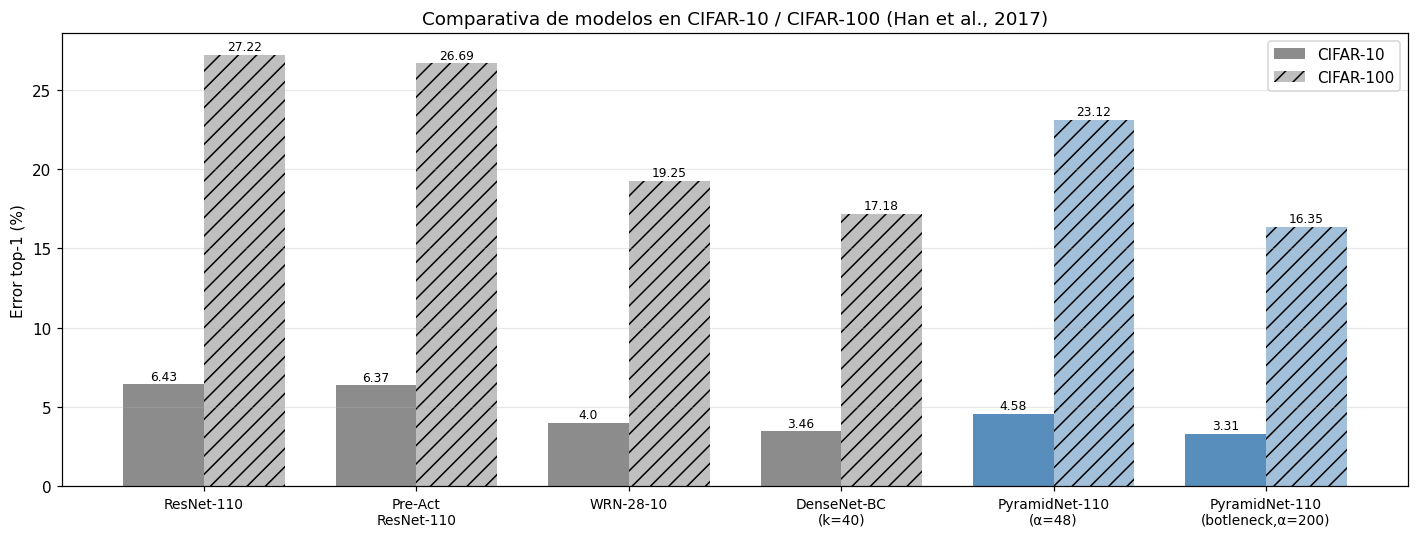

In [ ]:
# ── Paper results bar chart ───────────────────────────────────────────────
models   = ['ResNet-110', 'Pre-Act\nResNet-110', 'WRN-28-10',
            'DenseNet-BC\n(k=40)', 'PyramidNet-110\n(α=48)',
            'PyramidNet-110\n(botleneck,α=200)']
err_c10  = [6.43, 6.37, 4.00, 3.46, 4.58, 3.31]
err_c100 = [27.22, 26.69, 19.25, 17.18, 23.12, 16.35]
colors   = ['gray', 'gray', 'gray', 'gray', 'steelblue', 'steelblue']

x = np.arange(len(models))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, err_c10,  width, label='CIFAR-10',  color=colors, alpha=0.9)
bars2 = ax.bar(x + width/2, err_c100, width, label='CIFAR-100', color=colors, alpha=0.5, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('Error top-1 (%)')
ax.set_title('Comparativa de modelos en CIFAR-10 / CIFAR-100 (Han et al., 2017)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height()}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 📝 Resumen — PyramidNet

| Concepto | Lo que aprendimos |
|---|---|
| **Residual learning** | $y = \mathcal{F}(x) + x$ facilita entrenamiento profundo |
| **Problema ResNet** | Canales se duplican abruptamente → desequilibrio de parámetros |
| **Additive schedule** | $D_k = D_0 + \lfloor\alpha k/N\rfloor$ → crecimiento gradual y uniforme |
| **Zero-padding** | Conexiones de salto sin proyecciones costosas |
| **BN/ReLU positions** | Eliminar primer ReLU + BN final → mejora estabilidad y accuracy |
| **Factor α** | Mayor α → más canales → mayor capacidad → mejor accuracy |
| **Resultados** | Supera a DenseNet con parámetros comparables |

### Ventajas de PyramidNet
* Distribución **uniforme** de parámetros a lo largo de la red.
* Sin hiperparámetros complejos de agrupación.
* Compatible con cualquier bloque residual (basic, bottleneck).
* **Estado del arte** en CIFAR-10/100 en 2017.


---
---
# Resumen General

## Comparativa: DBM vs PyramidNet

| Característica | Deep Boltzmann Machine | PyramidNet |
|---|---|---|
| **Tipo** | Modelo generativo, no dirigido | Modelo discriminativo, supervisado |
| **Aprendizaje** | No supervisado (sin etiquetas) | Supervisado (con etiquetas) |
| **Tarea principal** | Generación, representación | Clasificación de imágenes |
| **Arquitectura** | Capas de unidades binarias estocásticas | Capas convolucionales con bloques residuales |
| **Entrenamiento** | CD-k + inferencia variacional + SAP | SGD + backpropagation |
| **Inferencia** | Muestreo de Gibbs + mean-field | Pase hacia adelante (determinista) |
| **Innovación clave** | Pre-entrenamiento greedy + inferencia bidireccional | Crecimiento gradual de canales (pirámide) |
| **Dataset demo** | MNIST (binarizado) | CIFAR-10 |
| **Año** | 2009 | 2017 (CVPR) |

## Conexión profunda

Ambos modelos comparten una idea fundamental:

> **La profundidad y la jerarquía permiten aprender representaciones cada vez más abstractas.**

* Las DBMs construyen jerarquías *estocásticas* de características latentes.
* PyramidNet construye jerarquías *deterministas* de mapas de características convolucionales, con una distribución más equilibrada de la capacidad.


---
## Referencias

**Deep Boltzmann Machines:**

- Salakhutdinov, R. & Hinton, G. (2009). *Deep Boltzmann Machines*. Proceedings of the 12th International Conference on Artificial Intelligence and Statistics (AISTATS). JMLR: W&CP 5, pp. 448–455.
- Hinton, G. E. (2002). *Training products of experts by minimizing contrastive divergence*. Neural Computation, 14(8), 1711–1800.
- Hinton, G. E., Osindero, S., & Teh, Y. W. (2006). *A fast learning algorithm for deep belief nets*. Neural Computation, 18(7), 1527–1554.
- Smolensky, P. (1986). *Information processing in dynamical systems: Foundations of harmony theory*. Parallel Distributed Processing, MIT Press.

**PyramidNet:**

- Han, D., Kim, J., & Kim, J. (2017). *Deep Pyramidal Residual Networks*. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), pp. 5927–5935.
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition*. CVPR, pp. 770–778.
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Identity Mappings in Deep Residual Networks*. ECCV, pp. 630–645.
- Tsang, S. (2019). *Review: PyramidNet — Deep Pyramidal Residual Networks*. Medium.
